In [8]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [9]:
df = pd.read_excel("Cleaned data.xlsx")
df.head()

,Group column,Order ID,Order Date,Customer,City,Pincode,Product,Category,Quantity,Unit Price,Discount,GST,Net Amount,Payment Mode,Delivery Status
0,0,BLK1025495,2026-06-26,Aditya Malhotra,Noida,201301,Britannia Bread 400g,Bakery,2,48,6,4.32,94.32,UPI,Delivered
1,1,BLK1025496,2026-06-26,Nidhi Arora,Delhi,110034,Lay's Magic Masala 52g,Snacks,5,20,10,8.10,98.10,Wallet,Delivered
2,2,BLK1025497,2026-06-26,Karan Gupta,Ghaziabad,201001,Surf Excel Easy Wash 1kg,Household,1,235,20,38.70,253.70,COD,Delivered
3,3,BLK1025498,2026-06-26,Pooja Verma,Gurgaon,122002,Dettol Hand Wash 900ml,Personal Care,2,185,25,62.10,407.10,UPI,Delivered
4,4,BLK1025499,2026-06-26,Saurabh Jain,Faridabad,121003,Haldiram Bhujia 400g,Snacks,3,145,18,37.53,454.53,Credit Card,Cancelled


In [10]:
df.describe()


,Group column,Order Date,Pincode,Quantity,Unit Price,Discount,GST,Net Amount
count,210.000000,210,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,104.500000,2026-06-29 18:37:42.857142,149983.985714,2.119048,220.338095,20.809524,20.773238,363.001810
min,0.000000,2026-06-26 00:00:00,110015.000000,1.000000,20.000000,4.000000,3.420000,83.420000
25%,52.250000,2026-06-30 00:00:00,110085.000000,1.000000,125.000000,15.000000,14.150000,278.250000
50%,104.500000,2026-06-30 00:00:00,122011.000000,2.000000,185.000000,20.000000,18.000000,351.750000
75%,156.750000,2026-06-30 00:00:00,201014.000000,2.000000,285.000000,25.000000,23.662500,430.700000
max,209.000000,2026-06-30 00:00:00,201309.000000,6.000000,945.000000,75.000000,81.900000,913.500000
std,60.765944,NaN,42131.196836,1.049091,150.782441,10.259872,12.754774,143.143151


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Group column     210 non-null    int64         
 1   Order ID         210 non-null    str           
 2   Order Date       210 non-null    datetime64[us]
 3   Customer         210 non-null    str           
 4   City             210 non-null    str           
 5   Pincode          210 non-null    int64         
 6   Product          210 non-null    str           
 7   Category         210 non-null    str           
 8   Quantity         210 non-null    int64         
 9   Unit Price       210 non-null    int64         
 10  Discount         210 non-null    int64         
 11  GST              210 non-null    float64       
 12  Net Amount       210 non-null    float64       
 13  Payment Mode     210 non-null    str           
 14  Delivery Status  210 non-null    str           
dtype

In [12]:
df.head()


,Group column,Order ID,Order Date,Customer,City,Pincode,Product,Category,Quantity,Unit Price,Discount,GST,Net Amount,Payment Mode,Delivery Status
0,0,BLK1025495,2026-06-26,Aditya Malhotra,Noida,201301,Britannia Bread 400g,Bakery,2,48,6,4.32,94.32,UPI,Delivered
1,1,BLK1025496,2026-06-26,Nidhi Arora,Delhi,110034,Lay's Magic Masala 52g,Snacks,5,20,10,8.10,98.10,Wallet,Delivered
2,2,BLK1025497,2026-06-26,Karan Gupta,Ghaziabad,201001,Surf Excel Easy Wash 1kg,Household,1,235,20,38.70,253.70,COD,Delivered
3,3,BLK1025498,2026-06-26,Pooja Verma,Gurgaon,122002,Dettol Hand Wash 900ml,Personal Care,2,185,25,62.10,407.10,UPI,Delivered
4,4,BLK1025499,2026-06-26,Saurabh Jain,Faridabad,121003,Haldiram Bhujia 400g,Snacks,3,145,18,37.53,454.53,Credit Card,Cancelled


In [13]:



df.columns=df.columns.str.lower().str.replace(" ","_")

df['revenue']=df['quantity']*df['unit_price']-df['discount']
df.head()

,group_column,order_id,order_date,customer,city,pincode,product,category,quantity,unit_price,discount,gst,net_amount,payment_mode,delivery_status,revenue
0,0,BLK1025495,2026-06-26,Aditya Malhotra,Noida,201301,Britannia Bread 400g,Bakery,2,48,6,4.32,94.32,UPI,Delivered,90
1,1,BLK1025496,2026-06-26,Nidhi Arora,Delhi,110034,Lay's Magic Masala 52g,Snacks,5,20,10,8.10,98.10,Wallet,Delivered,90
2,2,BLK1025497,2026-06-26,Karan Gupta,Ghaziabad,201001,Surf Excel Easy Wash 1kg,Household,1,235,20,38.70,253.70,COD,Delivered,215
3,3,BLK1025498,2026-06-26,Pooja Verma,Gurgaon,122002,Dettol Hand Wash 900ml,Personal Care,2,185,25,62.10,407.10,UPI,Delivered,345
4,4,BLK1025499,2026-06-26,Saurabh Jain,Faridabad,121003,Haldiram Bhujia 400g,Snacks,3,145,18,37.53,454.53,Credit Card,Cancelled,417


### Dates and months present

In [14]:
df['order_date'].dt.month_name().unique()

<StringArray>
['June']
Length: 1, dtype: str

In [15]:
df['order_date'].unique()

<DatetimeArray>
['2026-06-26 00:00:00', '2026-06-27 00:00:00', '2026-06-28 00:00:00',
 '2026-06-29 00:00:00', '2026-06-30 00:00:00']
Length: 5, dtype: datetime64[us]

### Top 5 winning and losing product

In [16]:
print("Winners")
print("Sum of revenue")
print(df.groupby('product')['net_amount'].sum().sort_values(ascending=False).head())
print("Average of revenue")
print(df.groupby('product')['net_amount'].mean().sort_values(ascending=False).head())
print("no. of times brought")
df['product'].value_counts().head()


Winners
Sum of revenue
product
Cadbury Dairy Milk Silk 150g    1293.50
Pringles Original 107g          1240.25
Saffola Gold Oil 5L              913.50
Saffola Active Oil 5L            892.50
Tata Sampann Moong Dal 1kg       852.60
Name: net_amount, dtype: float64
Average of revenue
product
Saffola Gold Oil 5L                   913.50
Saffola Active Oil 5L                 892.50
Kellogg's Chocos Moon & Stars 700g    771.75
Kellogg's Chocos 650g                 750.25
Nivea Body Lotion 400ml               727.85
Name: net_amount, dtype: float64
no. of times brought


product
Pringles Original 107g          3
Amul Butter 500g                2
Coca Cola 750ml                 2
Colgate Strong Teeth 200g       2
Cadbury Dairy Milk Silk 150g    2
Name: count, dtype: int64

In [17]:
print("Losers")
print("Sum of revenue")
print(df.groupby('product')['net_amount'].sum().sort_values(ascending=True).head())
print("Average of revenue")
print(df.groupby('product')['net_amount'].mean().sort_values(ascending=True).head())
print("no. of times brought")
df['product'].value_counts().head()

Losers
Sum of revenue
product
Tata Salt Lite 1kg                    83.42
Lay's American Style Cream & Onion    87.20
Britannia Bread 400g                  94.32
Tata Salt 1kg                         96.22
Lay's Magic Masala 52g                98.10
Name: net_amount, dtype: float64
Average of revenue
product
Tata Salt Lite 1kg                    83.42
Lay's American Style Cream & Onion    87.20
Britannia Bread 400g                  94.32
Tata Salt 1kg                         96.22
Lay's Magic Masala 52g                98.10
Name: net_amount, dtype: float64
no. of times brought


product
Pringles Original 107g          3
Amul Butter 500g                2
Coca Cola 750ml                 2
Colgate Strong Teeth 200g       2
Cadbury Dairy Milk Silk 150g    2
Name: count, dtype: int64

### Top 5 cities in terms of revenue

In [18]:
print("Sum of revenue")
print(df.groupby('city')['net_amount'].sum().sort_values(ascending=False))
print("Average of revenue")
print(df.groupby('city')['net_amount'].mean().sort_values(ascending=False))
print("no. of times brought")
df['city'].value_counts()

Sum of revenue
city
Delhi        23509.16
Gurgaon      16052.63
Noida        15553.80
Ghaziabad    14147.16
Faridabad     6967.63
Name: net_amount, dtype: float64
Average of revenue
city
Gurgaon      382.205476
Delhi        373.161270
Ghaziabad    353.679000
Noida        353.495455
Faridabad    331.791905
Name: net_amount, dtype: float64
no. of times brought


city
Delhi        63
Noida        44
Gurgaon      42
Ghaziabad    40
Faridabad    21
Name: count, dtype: int64

### Delivery status 

In [19]:
df['delivery_status'].unique()

<StringArray>
[' Delivered', ' Cancelled']
Length: 2, dtype: str

In [20]:
print("Sum of revenue")
print(df.groupby('delivery_status')['net_amount'].sum().sort_values(ascending=False))
print("Average of revenue")
print(df.groupby('delivery_status')['net_amount'].mean().sort_values(ascending=False))
print("no. of times brought")
df['delivery_status'].value_counts()


Sum of revenue
delivery_status
Delivered    71960.26
Cancelled     4270.12
Name: net_amount, dtype: float64
Average of revenue
delivery_status
Cancelled    427.0120
Delivered    359.8013
Name: net_amount, dtype: float64
no. of times brought


delivery_status
Delivered    200
Cancelled     10
Name: count, dtype: int64

### Top 5 categories generating high revenue

In [21]:

print("Sum of revenue")
print(df.groupby('category')['net_amount'].sum().sort_values(ascending=False).head())
print("Average of revenue")
print(df.groupby('category')['net_amount'].mean().sort_values(ascending=False).head())
print("no. of times brought")
df['category'].value_counts().head()

Sum of revenue
category
Grocery          16542.11
Personal Care    13968.24
Snacks           10121.54
Beverages         8848.45
Household         7915.42
Name: net_amount, dtype: float64
Average of revenue
category
Chocolates       496.666667
Breakfast        489.775000
Health Drinks    481.400000
Grocery          413.552750
Personal Care    399.092571
Name: net_amount, dtype: float64
no. of times brought


category
Grocery          40
Snacks           36
Personal Care    35
Beverages        30
Household        21
Name: count, dtype: int64

### Payment mode and revenue

In [22]:
print("Sum of revenue")
print(df.groupby('payment_mode')['net_amount'].sum().sort_values(ascending=False))
print("Average of revenue")
print(df.groupby('payment_mode')['net_amount'].mean().sort_values(ascending=False))
print("no. of times brought")
df['payment_mode'].value_counts()


Sum of revenue
payment_mode
UPI            28082.06
COD            17506.23
Credit Card    17109.05
Wallet         13533.04
Name: net_amount, dtype: float64
Average of revenue
payment_mode
Credit Card    397.884884
COD            372.472979
UPI            360.026410
Wallet         322.215238
Name: net_amount, dtype: float64
no. of times brought


payment_mode
UPI            78
COD            47
Credit Card    43
Wallet         42
Name: count, dtype: int64

### Correlations


In [23]:
df.corr(numeric_only=True)

,group_column,pincode,quantity,unit_price,discount,gst,net_amount,revenue
group_column,1.000000,-0.006442,0.008143,0.033307,0.003361,-0.074120,-0.019541,-0.013614
pincode,-0.006442,1.000000,-0.301637,0.095306,-0.045305,0.103396,-0.055245,-0.067837
quantity,0.008143,-0.301637,1.000000,-0.659772,-0.397513,-0.225419,-0.240560,-0.232033
unit_price,0.033307,0.095306,-0.659772,1.000000,0.914318,0.488258,0.703661,0.694765
discount,0.003361,-0.045305,-0.397513,0.914318,1.000000,0.548493,0.783142,0.772764
gst,-0.074120,0.103396,-0.225419,0.488258,0.548493,1.000000,0.589690,0.526829
net_amount,-0.019541,-0.055245,-0.240560,0.703661,0.783142,0.589690,1.000000,0.997128
revenue,-0.013614,-0.067837,-0.232033,0.694765,0.772764,0.526829,0.997128,1.000000


In [24]:
df.head()

,group_column,order_id,order_date,customer,city,pincode,product,category,quantity,unit_price,discount,gst,net_amount,payment_mode,delivery_status,revenue
0,0,BLK1025495,2026-06-26,Aditya Malhotra,Noida,201301,Britannia Bread 400g,Bakery,2,48,6,4.32,94.32,UPI,Delivered,90
1,1,BLK1025496,2026-06-26,Nidhi Arora,Delhi,110034,Lay's Magic Masala 52g,Snacks,5,20,10,8.10,98.10,Wallet,Delivered,90
2,2,BLK1025497,2026-06-26,Karan Gupta,Ghaziabad,201001,Surf Excel Easy Wash 1kg,Household,1,235,20,38.70,253.70,COD,Delivered,215
3,3,BLK1025498,2026-06-26,Pooja Verma,Gurgaon,122002,Dettol Hand Wash 900ml,Personal Care,2,185,25,62.10,407.10,UPI,Delivered,345
4,4,BLK1025499,2026-06-26,Saurabh Jain,Faridabad,121003,Haldiram Bhujia 400g,Snacks,3,145,18,37.53,454.53,Credit Card,Cancelled,417


array([[<Axes: title={'center': 'group_column'}>,
        <Axes: title={'center': 'order_date'}>,
        <Axes: title={'center': 'pincode'}>],
       [<Axes: title={'center': 'quantity'}>,
        <Axes: title={'center': 'unit_price'}>,
        <Axes: title={'center': 'discount'}>],
       [<Axes: title={'center': 'gst'}>,
        <Axes: title={'center': 'net_amount'}>,
        <Axes: title={'center': 'revenue'}>]], dtype=object)

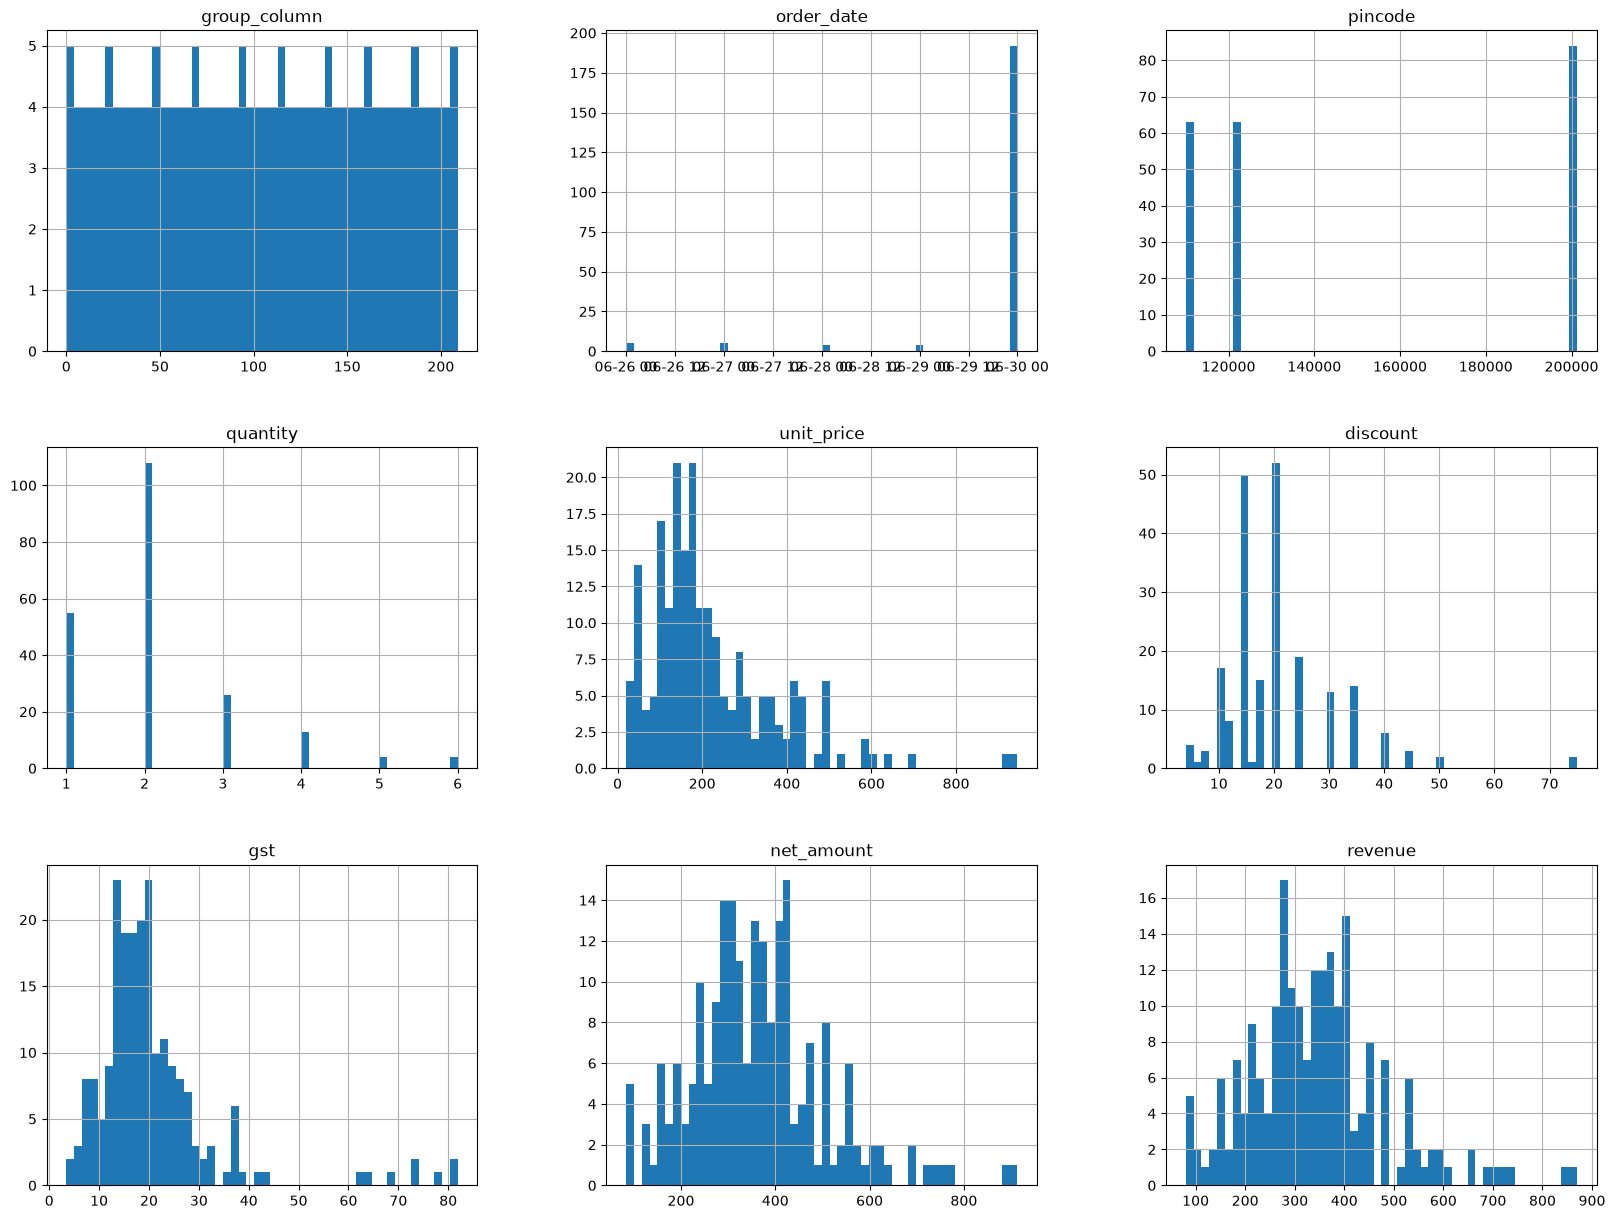

In [25]:
df.hist(bins=50, figsize=(20,15))


In [26]:
from sklearn.metrics import r2_score


### Revenue using Unit price and Discount and Quantity

In [27]:
X=df[['unit_price','discount','quantity']]
y=df['revenue']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=22)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)

MSE: 6136.323507798771
RMSE: 78.33468904513997
R2: 0.5268842375852646


In [28]:
from sklearn.preprocessing import PolynomialFeatures
X = df[['unit_price', 'discount', 'quantity']]
y = df['revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=22
)

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

y_pred = model.predict(X_test_poly)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 5.025357647011522e-05
RMSE: 0.007088975699642031
R2: 0.9999999961254065


### Revenue using unit price (Prediction model)

In [ ]:
X=df[['unit_price']]
y=df['revenue']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=22
)

In [30]:
#Using Linera Regression

model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
print("Mse:",mse)
rmse = np.sqrt(mse)
print("Rmse:",rmse)
r2=r2_score(y_test,y_pred)
print("R2",r2)

Mse: 7903.948675993335
Rmse: 88.90415443607422
R2 0.3905988334583492


In [31]:
#using Decision tree regressor

model2=DecisionTreeRegressor(random_state=44)
model2.fit(X_train,y_train)
y_pred2=model2.predict(X_test)
mse2=mean_squared_error(y_test,y_pred2)
print("Mse:",mse2)
rmse2 = np.sqrt(mse2)
print("Rmse:",rmse2)
r2=r2_score(y_test,y_pred2)
print("R2",r2)

Mse: 10593.492764550265
Rmse: 102.92469462937582
R2 0.18323269632616335


In [32]:
#Using Random Forest Regressor

model3=RandomForestRegressor(random_state=44)
model3.fit(X_train,y_train)
y_pred3=model3.predict(X_test)
mse3=mean_squared_error(y_test,y_pred3)
print("Mse:",mse3)
rmse3 = np.sqrt(mse3)
print("Rmse:",rmse3)
r2=r2_score(y_test,y_pred3)
print("R2",r2)

Mse: 10740.45027822069
Rmse: 103.636143686557
R2 0.17190214701037299


In [33]:
#Using Polynomial Features
from sklearn.preprocessing import PolynomialFeatures

X=df[['unit_price']]
y=df['revenue']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=22
)

poly=PolynomialFeatures(degree=2)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)
model.fit(X_train_poly,y_train)
y_pred4=model.predict(X_test_poly)
mse4=mean_squared_error(y_test,y_pred4)
rmse4=np.sqrt(mse4)
print("Mse:",mse4)
print("Rmse:",rmse4)
r2=r2_score(y_test,y_pred4)
print("R2",r2)

Mse: 7751.843356025445
Rmse: 88.04455324451051
R2 0.4023262830187393


### Revenue using discount (Prediction model)

In [37]:
X=df[['discount']]
y=df['revenue']
X_train,X_test,y_train,y_test= train_test_split(
    X,y,test_size=0.2,random_state=22
)



In [40]:
df['discount'].corr(df['revenue'],'spearman')

np.float64(0.7560003891276306)

In [41]:
#Using Linear Regression model
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("mse:",mse)
print("rmse:",rmse)
print("r2:",r2)

mse: 6027.837597695959
rmse: 77.63914990322833
r2: 0.5352485935394963


In [42]:
#using polynomial features
x=df[['discount']]
y=df['revenue']
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=22
)

poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)
model.fit(x_train_poly,y_train)
y_pred=model.predict(x_test_poly)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("mse:",mse)
print("rmse:",rmse)
print("r2:",r2)


mse: 5596.4151622666095
rmse: 74.80919169638588
r2: 0.5685116303076144


### Revenue using unit price and discount


In [44]:
X=df[['discount','unit_price']]
y=df['revenue']
X_train,X_test,y_train,y_test= train_test_split(
    X,y,test_size=0.2,random_state=22
)
#Using Linear Regression model
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("mse:",mse)
print("rmse:",rmse)
print("r2:",r2)

mse: 6040.144226996271
rmse: 77.71836479878016
r2: 0.5342997419516077


In [45]:
#using polynomial features
x=df[['discount','unit_price']]
y=df['revenue']
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=22
)

poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)
model.fit(x_train_poly,y_train)
y_pred=model.predict(x_test_poly)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("mse:",mse)
print("rmse:",rmse)
print("r2:",r2)


mse: 5289.351395973449
rmse: 72.72792720800895
r2: 0.5921865078976069


### Revenue using quantity

In [47]:
X=df[['quantity']]
y=df['revenue']
X_train,X_test,y_train,y_test= train_test_split(
    X,y,test_size=0.2,random_state=22
)
#Using Linear Regression model
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("mse:",mse)
print("rmse:",rmse)
print("r2:",r2)

mse: 15046.660870410196
rmse: 122.66483143268977
r2: -0.16011035279555452


In [48]:
#using polynomial features
x=df[['quantity']]
y=df['revenue']
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=22
)

poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)
model.fit(x_train_poly,y_train)
y_pred=model.predict(x_test_poly)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("mse:",mse)
print("rmse:",rmse)
print("r2:",r2)


mse: 15035.630285935078
rmse: 122.61986089510573
r2: -0.15925988534917668


### Revenue using unit price and quantity

In [49]:
X=df[['quantity','unit_price']]
y=df['revenue']
X_train,X_test,y_train,y_test= train_test_split(
    X,y,test_size=0.2,random_state=22
)
#Using Linear Regression model
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("mse:",mse)
print("rmse:",rmse)
print("r2:",r2)

mse: 7041.843714417143
rmse: 83.91569408887197
r2: 0.45706785935948857


In [51]:
#using polynomial features
x=df[['quantity','unit_price']]
y=df['revenue']
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=22
)

poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)
model.fit(x_train_poly,y_train)
y_pred=model.predict(x_test_poly)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("mse:",mse)
print("rmse:",rmse)
print("r2:",r2)

mse: 6.885595162555205
rmse: 2.624041760825312
r2: 0.9994691147556234


### Revenue using quantity and discount

In [50]:
X=df[['quantity','discount']]
y=df['revenue']
X_train,X_test,y_train,y_test= train_test_split(
    X,y,test_size=0.2,random_state=22
)
#Using Linear Regression model
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("mse:",mse)
print("rmse:",rmse)
print("r2:",r2)

mse: 6088.649129329189
rmse: 78.02979641988814
r2: 0.5305599727202552


In [52]:
#using polynomial features
x=df[['quantity','discount']]
y=df['revenue']
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=22
)

poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)
model.fit(x_train_poly,y_train)
y_pred=model.predict(x_test_poly)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("mse:",mse)
print("rmse:",rmse)
print("r2:",r2)

mse: 3281.6925386288626
rmse: 57.28605885055161
r2: 0.7469787136465527


### Unit price using Revenue (Prediction model)

### Discount using Revenue (Prediction model)

### Discount using Unit price (Prediction model)